# AEMO SB3 online RL training notebook

Use this notebook to train an online SB3 policy directly on `AEMOBatteryTradingEnv`, with optional battery-size sweeps and rollout export for offline DT data generation.

In [ ]:
# Repository bootstrap for relocated notebooks
from pathlib import Path
import os
import sys

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "src").exists():
            return candidate
    return start

REPO_ROOT = _find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
for _extra_path in (REPO_ROOT, REPO_ROOT / "src"):
    _extra_str = str(_extra_path)
    if _extra_str not in sys.path:
        sys.path.insert(0, _extra_str)

DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
EVAL_OUTPUT_DIR = REPO_ROOT / "eval_output"
CONFIGS_DIR = REPO_ROOT / "configs"

# Runtime directory defaults for organized local artifacts
for _runtime_dir in (
    DATA_DIR / "household" / "raw",
    DATA_DIR / "household" / "splits",
    DATA_DIR / "household" / "logs",
    MODELS_DIR / "household" / "sb3",
    MODELS_DIR / "household" / "dt",
    MODELS_DIR / "aemo_sb3",
    MODELS_DIR / "aemo" / "dt",
):
    _runtime_dir.mkdir(parents=True, exist_ok=True)


In [1]:
from pathlib import Path
import sys
from datetime import datetime

import polars as pl
from stable_baselines3.common.vec_env import DummyVecEnv

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / 'src'))

In [2]:
from aemo_notebook_utils import (
    fetch_and_preprocess_aemo_data,
    fetch_and_preprocess_aemo_scenarios,
    fit_aemo_global_stats,
    make_aemo_env_fns,
    prepare_run_paths,
    resolve_battery_variants,
    train_sb3_model_on_aemo,
    SB3_MODEL_CLASSES
)
from decision import run_sb3_model_on_vec_env
from helper import flatten_episode_data

/usr/local/lib/python3.10/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 1. Training configuration

In [ ]:
SB3_MODEL_CLASSES

{'A2C': stable_baselines3.a2c.a2c.A2C,
 'DDPG': stable_baselines3.ddpg.ddpg.DDPG,
 'PPO': stable_baselines3.ppo.ppo.PPO,
 'SAC': stable_baselines3.sac.sac.SAC,
 'TD3': stable_baselines3.td3.td3.TD3}

In [12]:
SCENARIOS = [
    {
        'label': 'sa1_2020_2022',
        'region': 'SA1',
        'start_date': datetime.fromisoformat('2020-01-01'),
        'end_date': datetime.fromisoformat('2022-03-01'),
    },
    {
        'label': 'vic1_2019_2021',
        'region': 'VIC1',
        'start_date': datetime.fromisoformat('2019-01-01'),
        'end_date': datetime.fromisoformat('2021-03-01'),
    },
]

STEP_DURATION = 5 / 60
EPISODE_HOURS = 24*365*1.5
ACTION_MODE = 'multi_market'
DEGRADATION_MODE = 'real_world'
DEGRADATION_CHEMISTRY = 'LFP'
DEGRADATION_TEMPERATURE = 30.0

CACHE_DIR = REPO_ROOT / 'src' / 'data' / 'aemo'
OUTPUT_DIR = REPO_ROOT / 'models' / 'aemo_sb3'
RUN_TAG = 'aemo_sb3'
SB3_ALGORITHM = 'A2C'

BATTERY_VARIANTS = [
    {'name': 'small', 'capacity_mwh': 2.0, 'max_power_mw': 1.0, 'init_soc_ratio': 0.5},
    {'name': 'medium', 'capacity_mwh': 10.0, 'max_power_mw': 5.0, 'init_soc_ratio': 0.5},
    {'name': 'large', 'capacity_mwh': 50.0, 'max_power_mw': 25.0, 'init_soc_ratio': 0.5},
]

EPISODES_PER_VARIANT = 2
DEFAULT_MODEL = False
TEST_TIMESTEPS = 40_000
TOTAL_TIMESTEPS = 1000_000
N_TRIALS = 5
N_JOBS = 2
ROLLOUT_EPISODES_PER_VARIANT = 1
DETERMINISTIC_ROLLOUT = True

## 2. Fetch and cache AEMO data

In [4]:
run_paths = prepare_run_paths(output_dir=OUTPUT_DIR, dataset_tag=RUN_TAG)

global_stats, scenario_manifest = fit_aemo_global_stats(
    scenarios=SCENARIOS,
    cache_dir=CACHE_DIR,
    step_duration=STEP_DURATION,
    refresh=False,
)
processed_by_label, _ = fetch_and_preprocess_aemo_scenarios(
    scenarios=SCENARIOS,
    cache_dir=CACHE_DIR,
    step_duration=STEP_DURATION,
    refresh=False,
    fixed_stats=global_stats,
)
combined_processed_data = pl.concat(
    [
        df.with_columns(pl.lit(label).alias('scenario_label'))
        for label, df in processed_by_label.items()
    ],
    how='diagonal_relaxed',
).sort(['SETTLEMENTDATE', 'scenario_label'])
resolved_battery_variants = resolve_battery_variants(BATTERY_VARIANTS)
MAX_STEP = int(round(EPISODE_HOURS / STEP_DURATION))
scenario_manifest

Fetching AEMO data bundle for SA1 from 2020-01-01 to 2022-03-01...
Fetching dispatch price data for SA1 from 2020-01-01 to 2022-03-01...
INFO: Compiling data for table DISPATCHPRICE
INFO: Downloading data for table DISPATCHPRICE, year 2019, month 12
INFO: Creating feather file for DISPATCHPRICE, 2019, 12
INFO: Downloading data for table DISPATCHPRICE, year 2020, month 01
INFO: Creating feather file for DISPATCHPRICE, 2020, 01
INFO: Downloading data for table DISPATCHPRICE, year 2020, month 02
INFO: Creating feather file for DISPATCHPRICE, 2020, 02
INFO: Downloading data for table DISPATCHPRICE, year 2020, month 03
INFO: Creating feather file for DISPATCHPRICE, 2020, 03
INFO: Downloading data for table DISPATCHPRICE, year 2020, month 04
INFO: Creating feather file for DISPATCHPRICE, 2020, 04
INFO: Downloading data for table DISPATCHPRICE, year 2020, month 05
INFO: Creating feather file for DISPATCHPRICE, 2020, 05
INFO: Downloading data for table DISPATCHPRICE, year 2020, month 06
INFO: 

[{'label': 'sa1_2020_2022',
  'region': 'SA1',
  'start_date': datetime.datetime(2020, 1, 1, 0, 0),
  'end_date': datetime.datetime(2022, 3, 1, 0, 0),
  'index': 0},
 {'label': 'vic1_2019_2021',
  'region': 'VIC1',
  'start_date': datetime.datetime(2019, 1, 1, 0, 0),
  'end_date': datetime.datetime(2021, 3, 1, 0, 0),
  'index': 1}]

## 3. Train the SB3 model

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
[I 2026-04-12 15:45:19,476] A new study created in memory with name: no-name-0fbe57fe-2238-4b5e-8f0a-a22b8a90b398


Detected list of environment functions; using chunked training.
Tuning hyperparameters for class A2C...


[I 2026-04-12 15:51:02,991] Trial 0 finished with value: -1420.1631380000001 and parameters: {'learning_rate': 0.0002321436558674473, 'gamma': 0.9435033301536586, 'ent_coef': 0.0014091015026115952, 'vf_coef': 0.4687511955760969, 'net_arch': 'small'}. Best is trial 0 with value: -1420.1631380000001.
[I 2026-04-12 15:51:21,514] Trial 1 finished with value: -1391.6617783333331 and parameters: {'learning_rate': 0.0003837684810566194, 'gamma': 0.9261334566919587, 'ent_coef': 0.007028174262831522, 'vf_coef': 0.13450042313560345, 'net_arch': 'medium'}. Best is trial 1 with value: -1391.6617783333331.
[I 2026-04-12 15:57:00,454] Trial 2 finished with value: -1319.2165796666668 and parameters: {'learning_rate': 0.0005282207119039201, 'gamma': 0.9395956763242825, 'ent_coef': 0.007219405262677501, 'vf_coef': 0.3568487992040936, 'net_arch': 'large'}. Best is trial 2 with value: -1319.2165796666668.
[I 2026-04-12 15:57:18,702] Trial 3 finished with value: -1264.6725506666667 and parameters: {'learn

Best trial for class A2C:
{'learning_rate': 0.0003591965130367772, 'gamma': 0.9479826875224416, 'ent_coef': 0.005264268482675262, 'vf_coef': 0.8630336893263039, 'net_arch': 'large'}


/usr/local/lib/python3.10/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/pytho

Training the model with the best hyperparameters...
Chunk 1: envs=6, steps=1000000
training complete.


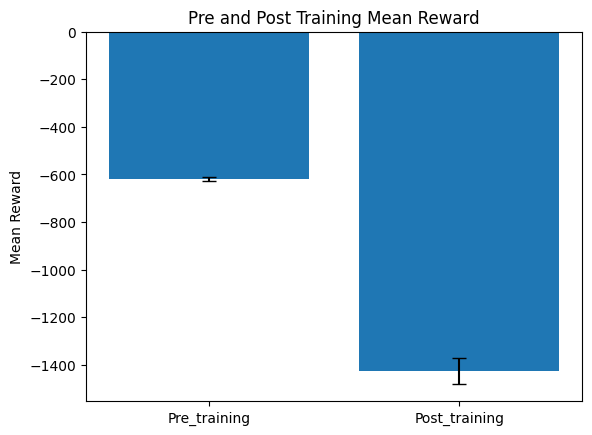

/code/models/aemo_sb3/a2c_aemo_model.zip


{'Pre_training': {'mean_reward': np.float64(-618.1338148),
  'std_reward': np.float64(8.840671108021255)},
 'Post_training': {'mean_reward': np.float64(-1425.2099928),
  'std_reward': np.float64(53.65558059136225)}}

In [13]:
model, eval_result = train_sb3_model_on_aemo(
    processed_data=combined_processed_data,
    algorithm=SB3_ALGORITHM,
    battery_variants=resolved_battery_variants,
    episodes_per_variant=EPISODES_PER_VARIANT,
    max_step=MAX_STEP,
    step_duration=STEP_DURATION,
    action_mode=ACTION_MODE,
    degradation_mode=DEGRADATION_MODE,
    degradation_chemistry=DEGRADATION_CHEMISTRY,
    degradation_temperature=DEGRADATION_TEMPERATURE,
    random_episode_start=True,
    test_timesteps=TEST_TIMESTEPS,
    total_timesteps=TOTAL_TIMESTEPS,
    n_trials=N_TRIALS,
    n_jobs=N_JOBS,
    default_model=DEFAULT_MODEL,
)

MODEL_PATH = run_paths['output_dir'] / f'{SB3_ALGORITHM.lower()}_aemo_model.zip'
model.save(MODEL_PATH)
print(MODEL_PATH)
eval_result

## 4. Export rollout logs for evaluation or offline DT data

In [ ]:
rollout_env_fns = make_aemo_env_fns(
    processed_data=combined_processed_data,
    battery_variants=resolved_battery_variants,
    episodes_per_variant=ROLLOUT_EPISODES_PER_VARIANT,
    max_step=MAX_STEP,
    step_duration=STEP_DURATION,
    action_mode=ACTION_MODE,
    degradation_mode=DEGRADATION_MODE,
    degradation_chemistry=DEGRADATION_CHEMISTRY,
    degradation_temperature=DEGRADATION_TEMPERATURE,
    random_episode_start=True,
)
rollout_vec_env = DummyVecEnv(rollout_env_fns)
try:
    episode_data = run_sb3_model_on_vec_env(model, rollout_vec_env, deterministic=DETERMINISTIC_ROLLOUT, max_steps=MAX_STEP)
finally:
    rollout_vec_env.close()

rollout_df = flatten_episode_data(episode_data)
rollout_path = run_paths['raw_dir'] / f'{SB3_ALGORITHM.lower()}_rollouts.parquet'
rollout_df.write_parquet(rollout_path)
print(rollout_path)
rollout_df.head()

## 5. Optional next step

Use the exported SB3 rollout parquet inside `aemo_simrun.ipynb` by adding it to the `BEHAVIOR_RUNS` config as an SB3 behavior source, or merge it into the DT dataset manually.